In [34]:
import pandas as pd
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import plot_grouped_histograms

from bs4 import BeautifulSoup

from catboost import CatBoostRegressor

from kmeanscluster import KMeansCluster

from lightgbm import LGBMRegressor

from optuna import create_study

from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

from time import time

from toolbox_ML_v2 import describe_df, tipifica_variables

from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features

from xgboost import XGBRegressor

import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|')

# Extracción de datos

In [35]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df]).reset_index(drop=True)
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/navalcarnero/648872.html


# Train test split

In [36]:
X = df.drop(columns='precio')
y = df['precio'].astype(str).str.extract(r'([\d\.]+) €').replace(r'\.', '', regex=True).astype(int)
y.describe()

,0
count,1.209000e+03
mean,2.976759e+05
std,1.824294e+05
min,4.490000e+04
25%,1.920000e+05
50%,2.500000e+05
75%,3.350000e+05
max,1.950000e+06


In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(967, 11)
(242, 11)
(967, 1)
(242, 1)


# Clustering No Supervisado

In [38]:
coordenadas = X_train[['latitud','longitud']]

In [39]:
scaler = StandardScaler()
coords = scaler.fit_transform(coordenadas)

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

ks = []
inertias = []
sil_scores = []
k_range = range(2,12)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=25)
    kmeans.fit(coords)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(coordenadas, kmeans.labels_))
    ks.append(k)

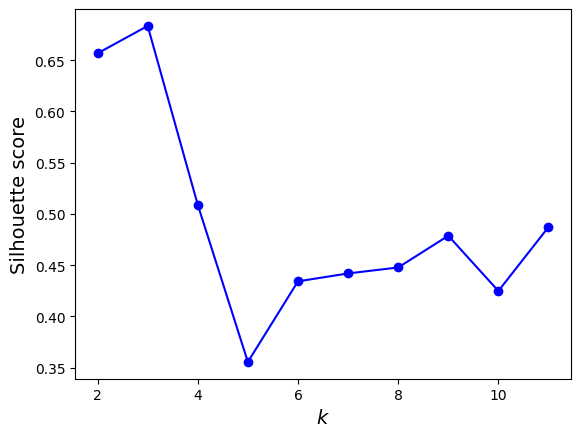

In [41]:
plt.plot(ks, sil_scores, "bo-");
plt.xlabel("$k$", fontsize=14);
plt.ylabel("Silhouette score", fontsize=14)
plt.show()

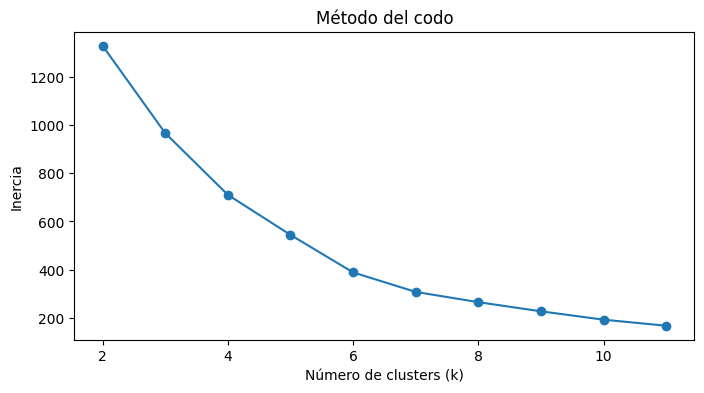

In [42]:
plt.figure(figsize=(8,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

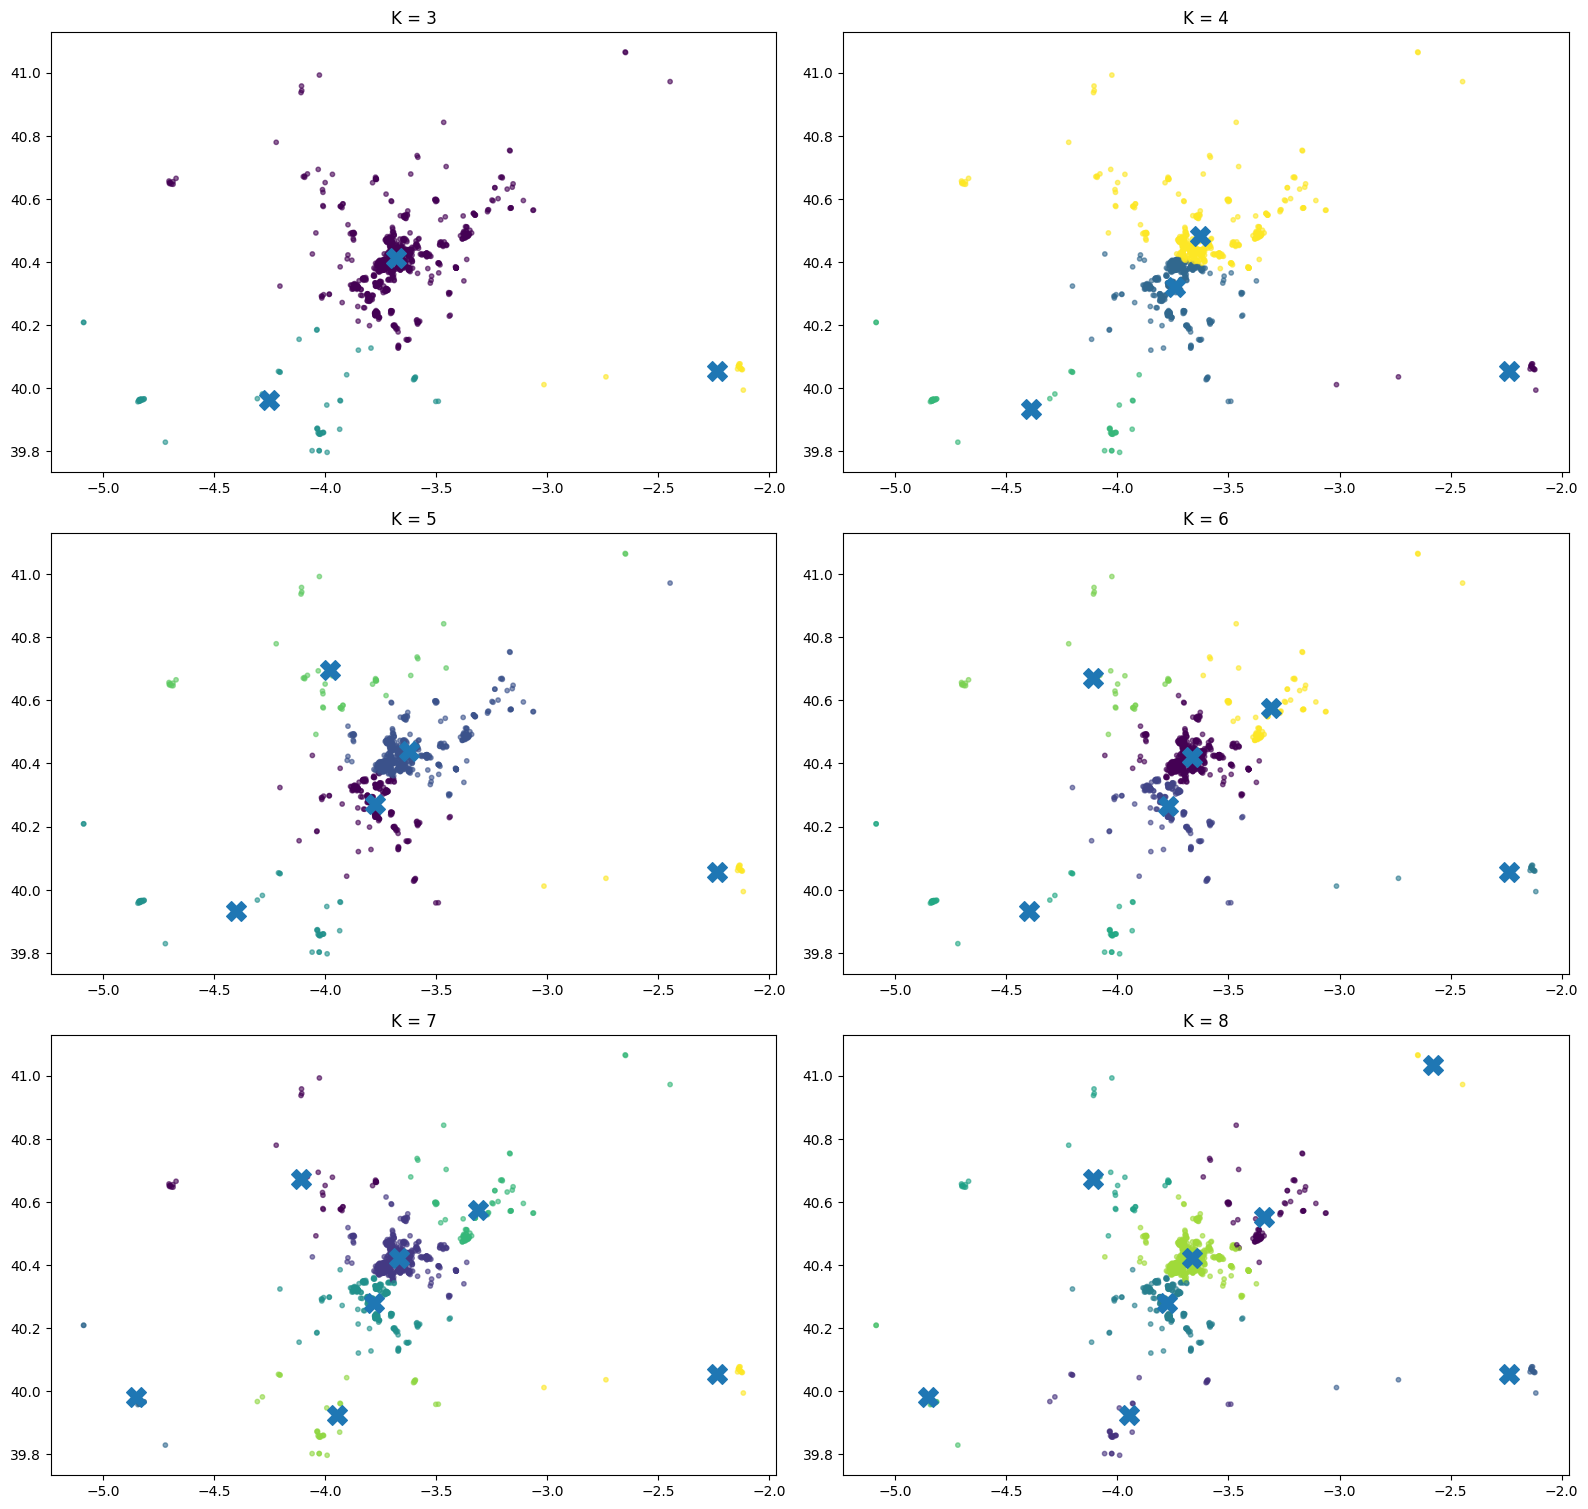

In [43]:
k_values = [3,4,5,6,7,8]

plt.figure(figsize=(16,30))

for i, k in enumerate(k_values):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(coords)
    
    centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    plt.subplot(6,2,i+1)

    plt.scatter(
        X_train['longitud'],
        X_train['latitud'],
        c=labels,
        s=10,
        alpha=0.6
    )

    plt.scatter(
        centroids[:,1],
        centroids[:,0],
        marker='X',
        s=200
    )

    plt.title(f"K = {k}")

plt.tight_layout()
plt.show()

In [44]:
k = 5

kmeans_final = KMeans(n_clusters=k, random_state=42, n_init=50)
kmeans_final.fit(coords)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",50
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


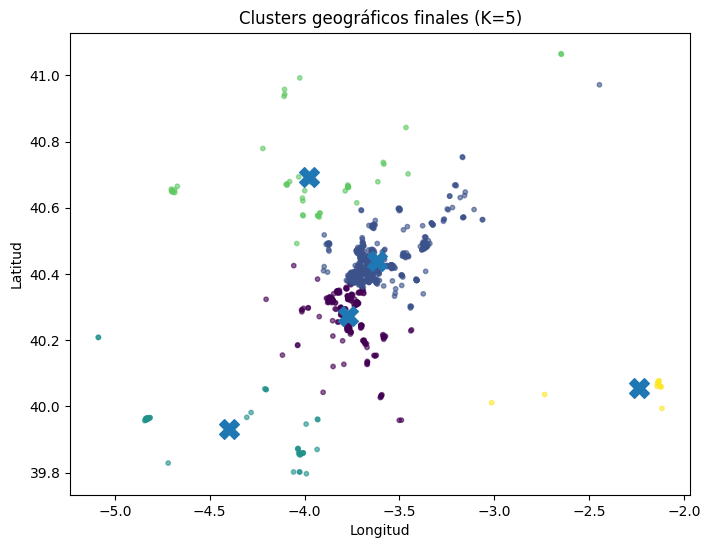

In [45]:
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
clusters = kmeans_final.predict(coords)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train['longitud'],
    X_train['latitud'],
    c=clusters,
    s=10,
    alpha=0.6
)

plt.scatter(
    centroids[:,1],
    centroids[:,0],
    marker='X',
    s=200
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title(f"Clusters geográficos finales (K={k})")
plt.show()

In [46]:
cluster_transformer = ColumnTransformer(
    [
        ('cluster', KMeansCluster(n_clusters=5), ['latitud','longitud'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')

# Pretratamiento de datos

In [47]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [48]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('cluster', cluster_transformer),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)
X_train_limpio.head()

,latitud,longitud,cluster,dormitorios,superficie_m2,baños,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
1055,40.489602,-3.886053,B,2.0,120.0,1.0,NaN,Independiente,1,Independiente,1990,1,False,29,240.6,50.4,3,140.0,5,320.0,5,770.0,1,2100.0,5,720.0,5,710.0,5,180.0,5,610.0,0,0,0,2.0,True
666,40.446802,-3.703233,B,2.0,42.0,1.0,2.0,Independiente,0,NO,1925,0,False,22,162.0,34.0,5,60.0,5,150.0,5,50.0,5,380.0,5,110.0,5,40.0,5,100.0,5,50.0,0,0,0,2.0,True
1014,40.494502,-3.693703,B,4.0,88.0,2.0,5.0,NO,1,NO,1979,0,False,24,294.0,61.0,5,40.0,5,60.0,5,70.0,5,890.0,5,220.0,5,340.0,5,330.0,5,310.0,0,0,0,2.0,True
650,40.484702,-3.359223,E,2.0,80.0,1.0,0.0,Independiente,0,Independiente,1965,0,True,24,NaN,NaN,4,90.0,5,60.0,5,150.0,5,740.0,5,170.0,5,90.0,5,150.0,5,150.0,0,1,0,NaN,False
899,40.435002,-3.706983,B,5.0,152.0,2.0,5.0,Centralizada,0,centralizada,1940,0,False,29,174.0,36.0,5,130.0,5,110.0,5,100.0,5,400.0,5,40.0,5,190.0,5,100.0,5,30.0,1,0,2,2.0,True


# MiniEDA

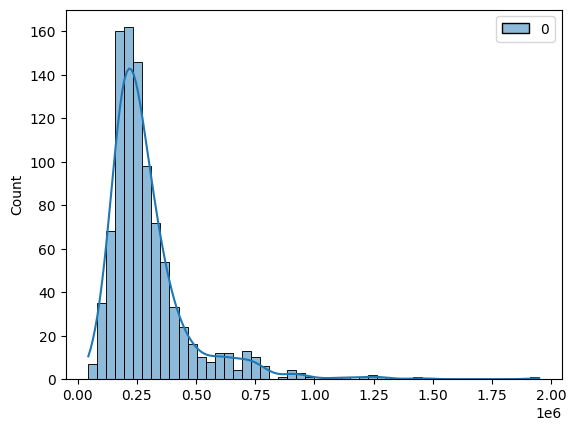

In [49]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [50]:
X_train_limpio.shape

(967, 37)

In [51]:
describe_df(X_train_limpio).T

Clasificación sugerida para 967 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


Columnas,Tipo_Dato,Nulos,Nulos_%,Cardinalidad,Cardinalidad_%,Clasificacion_sugerida
latitud,float64,0,0.0,833,86.14,Numerica_Continua
longitud,float64,0,0.0,945,97.72,Numerica_Continua
cluster,str,0,0.0,5,0.52,Categorica
dormitorios,float64,93,9.6,6,0.62,Categorica
superficie_m2,float64,0,0.0,159,16.44,Numerica_Continua
baños,float64,82,8.5,5,0.52,Categorica
planta,float64,365,37.7,13,1.34,Numerica_Discreta
aire_acondicionado,str,0,0.0,3,0.31,Categorica
ascensor,int64,0,0.0,2,0.21,Categorica_Binaria
calefaccion,str,0,0.0,3,0.31,Categorica


In [52]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categoricas = tipifica_variables(X_train_limpio)['Categorica']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

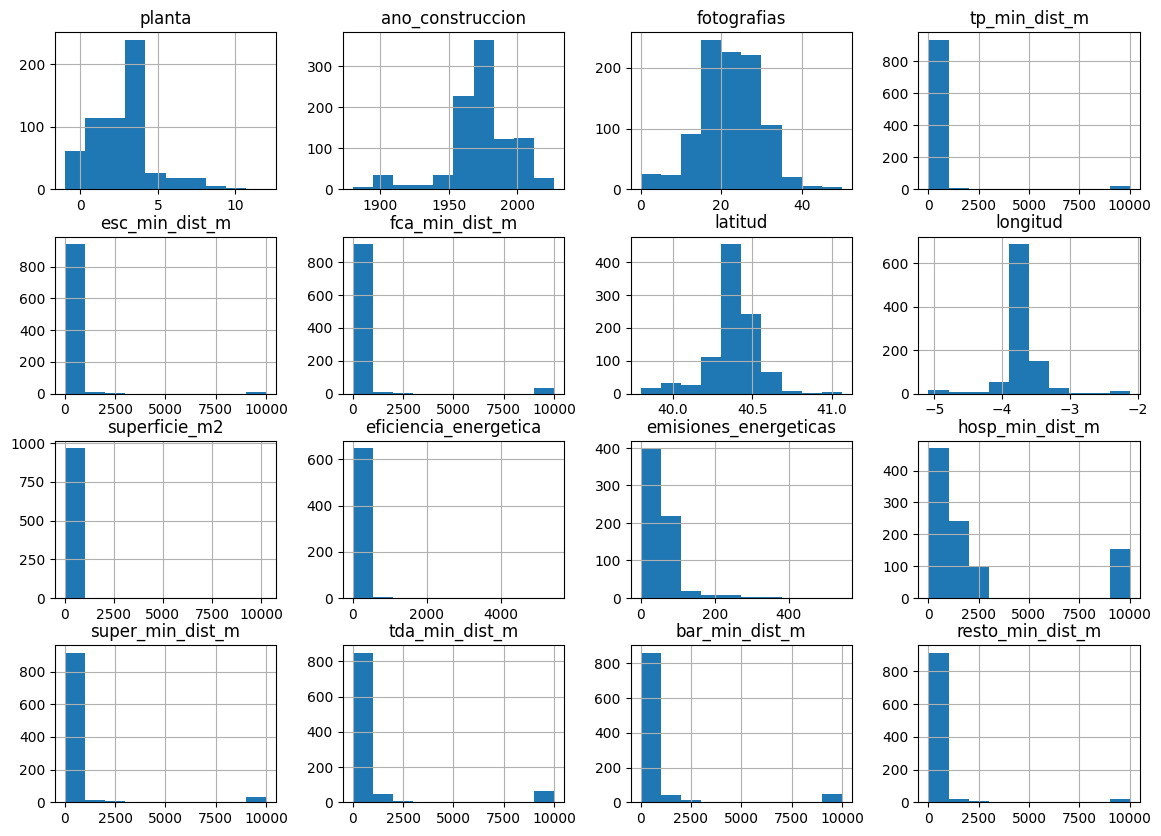

In [53]:
X_train_limpio[numericas].hist(figsize=(14, 10));

In [54]:
train_set = X_train_limpio.copy()
train_set['Precio'] = y_train.values  
target = 'Precio'

#### Analisis bivariante

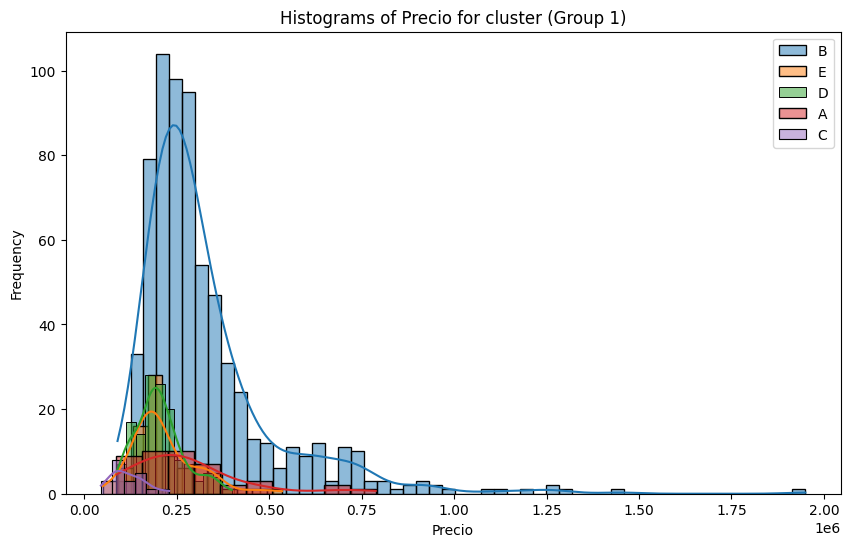

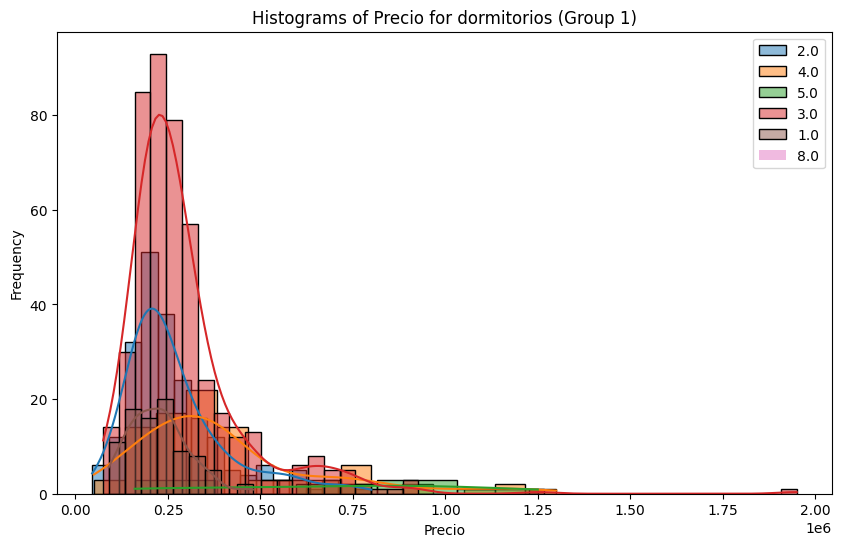

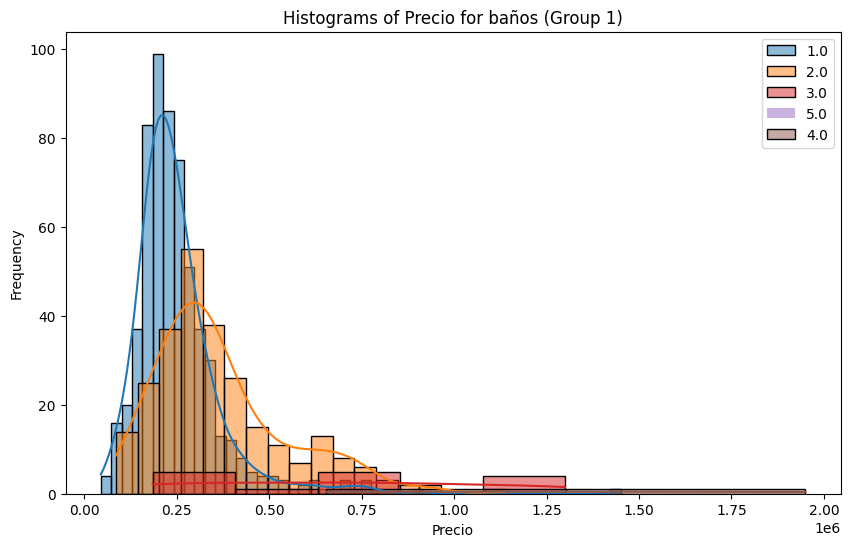

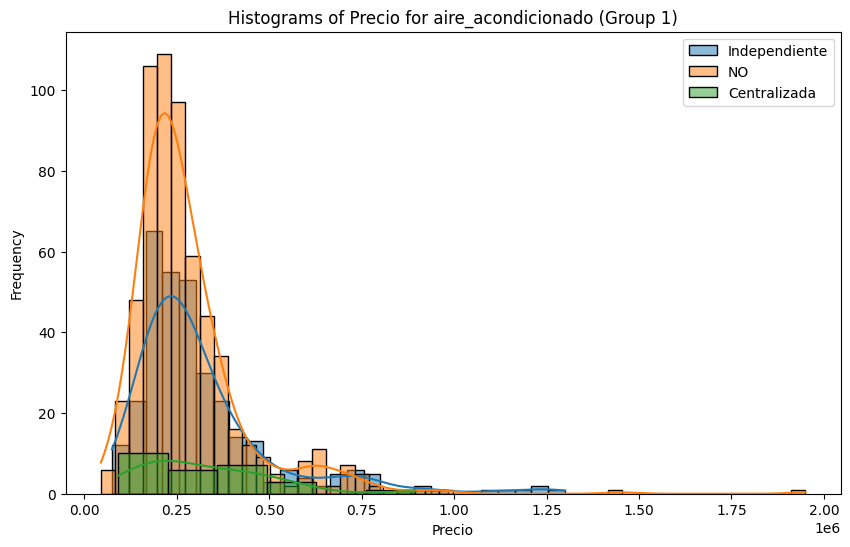

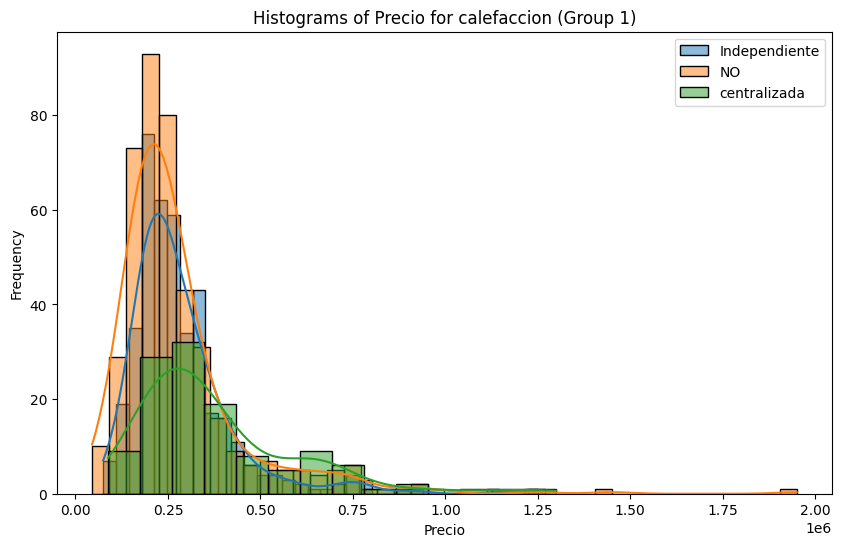

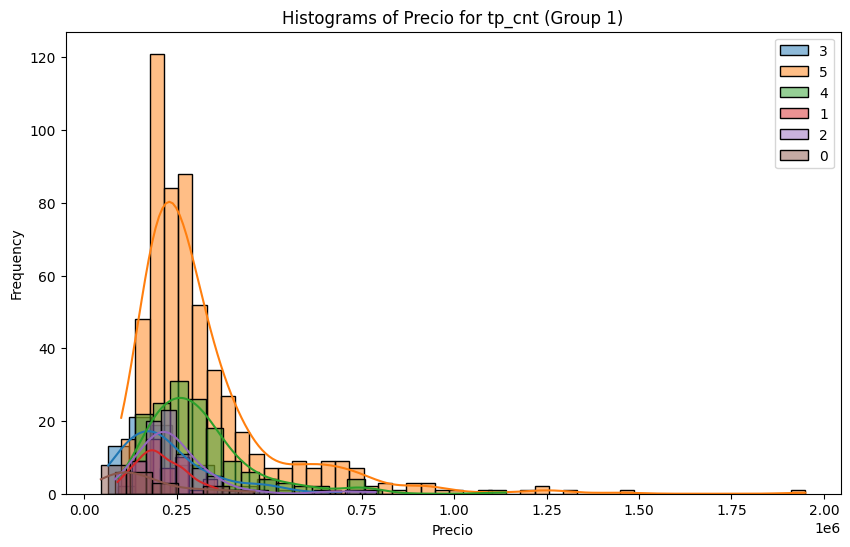

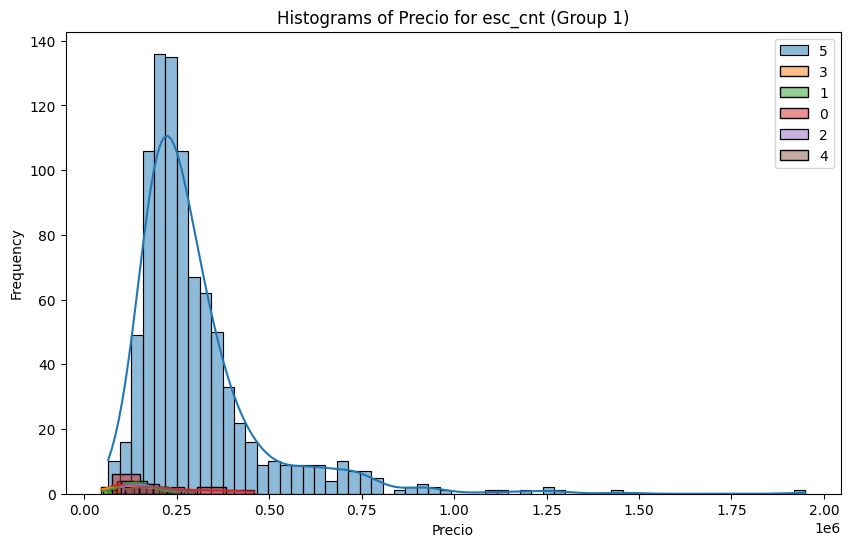

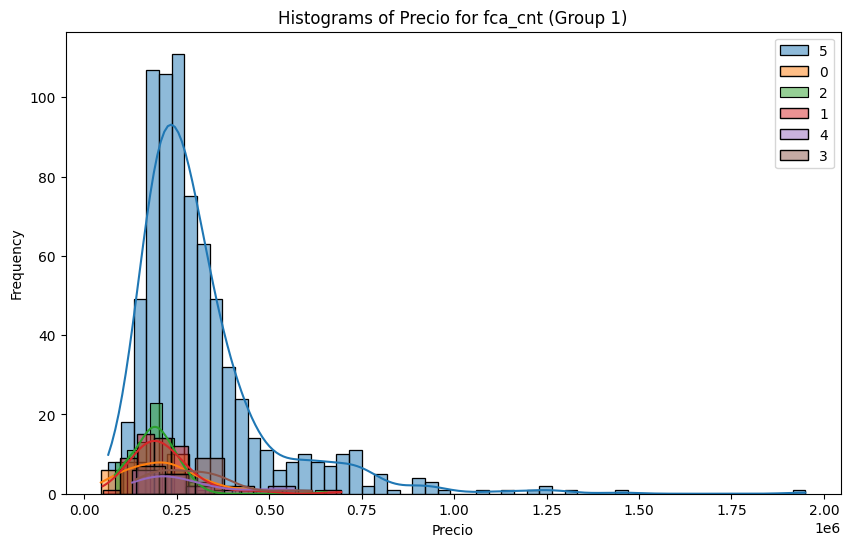

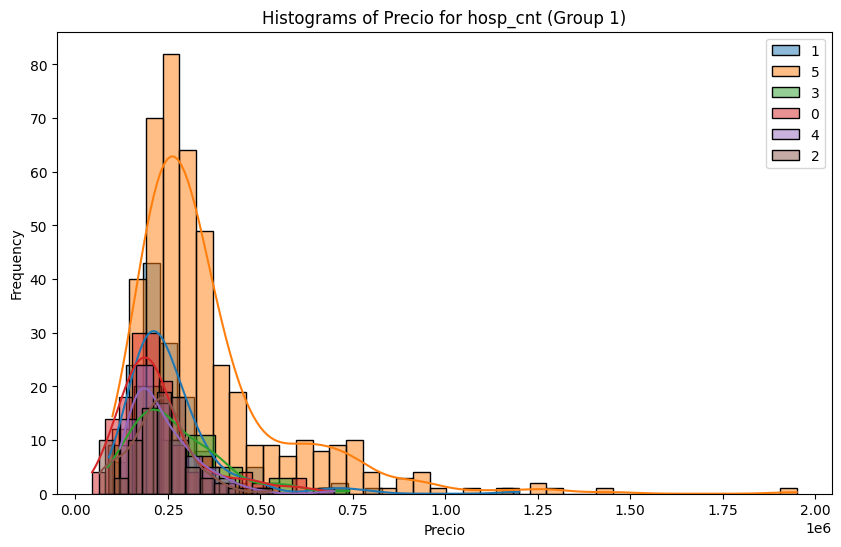

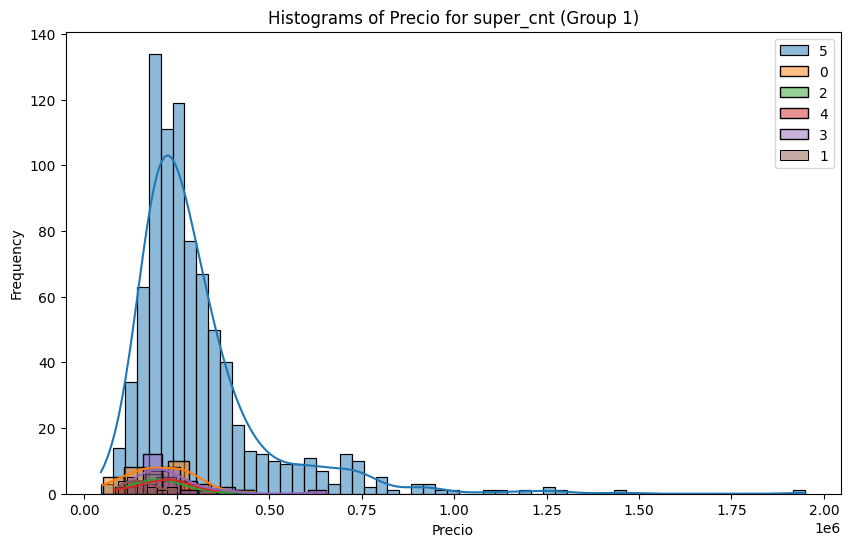

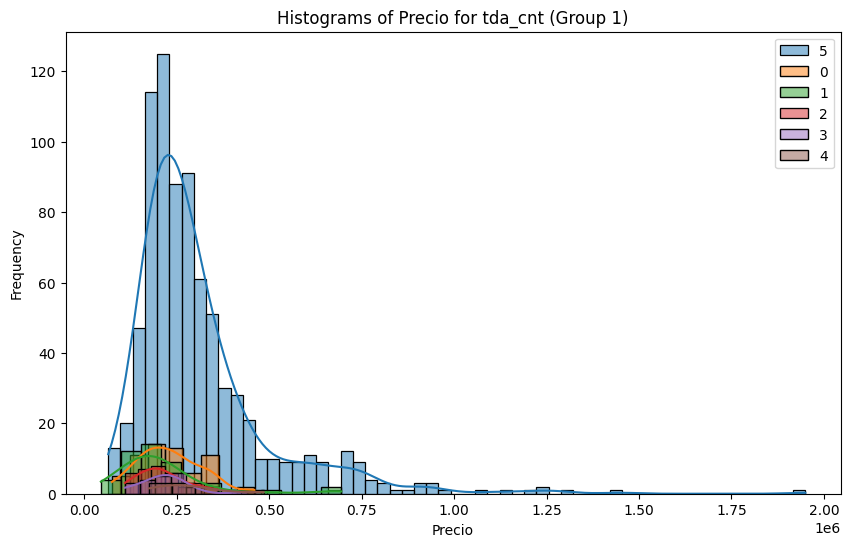

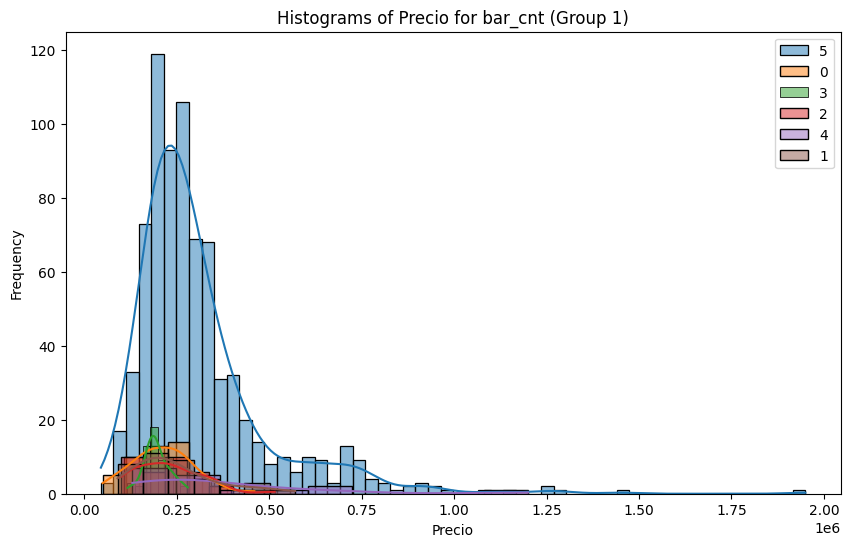

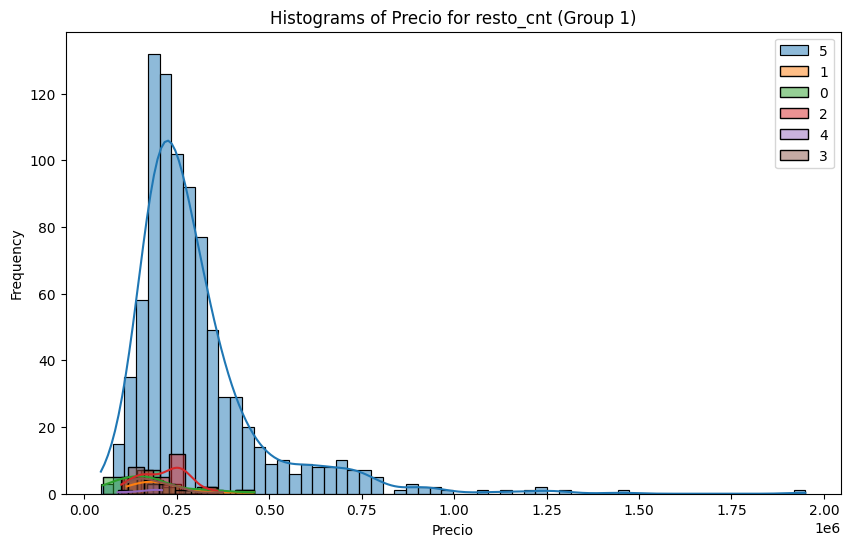

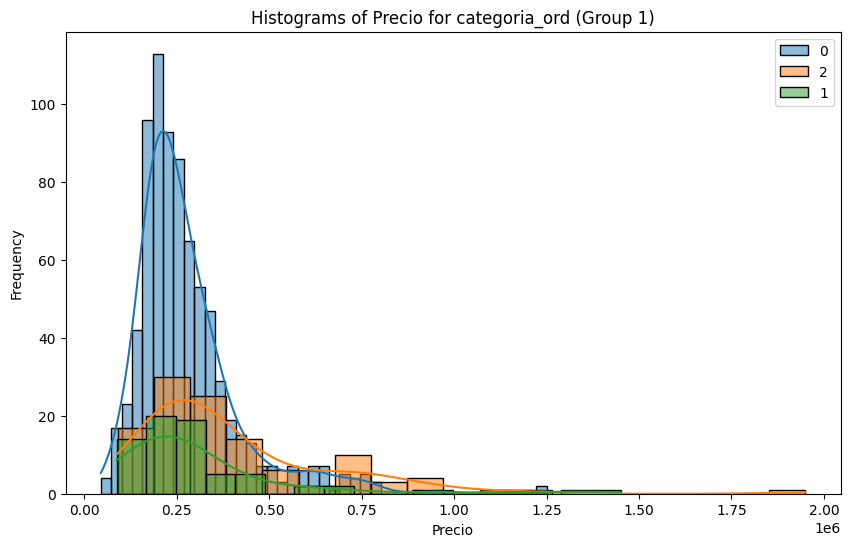

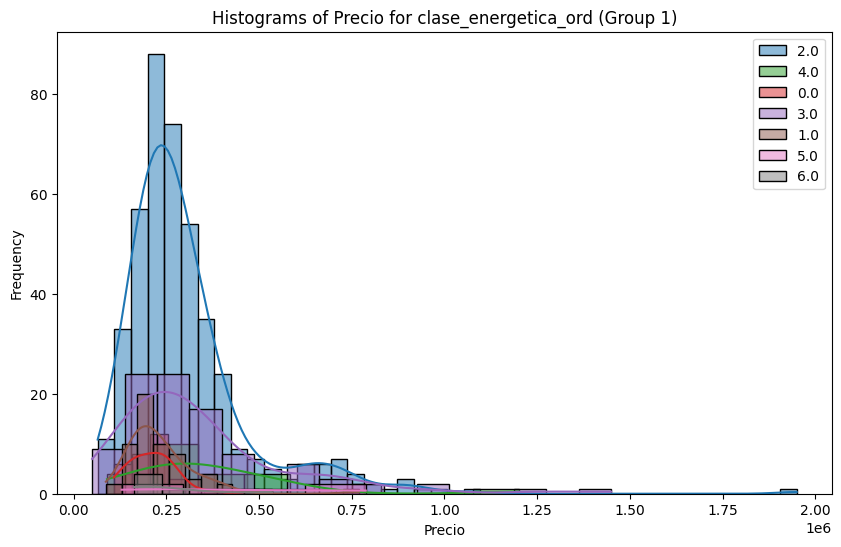

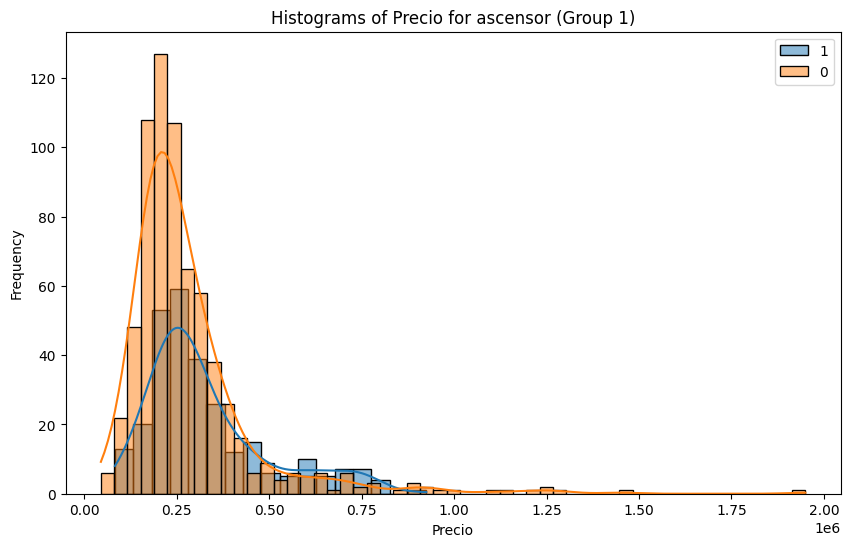

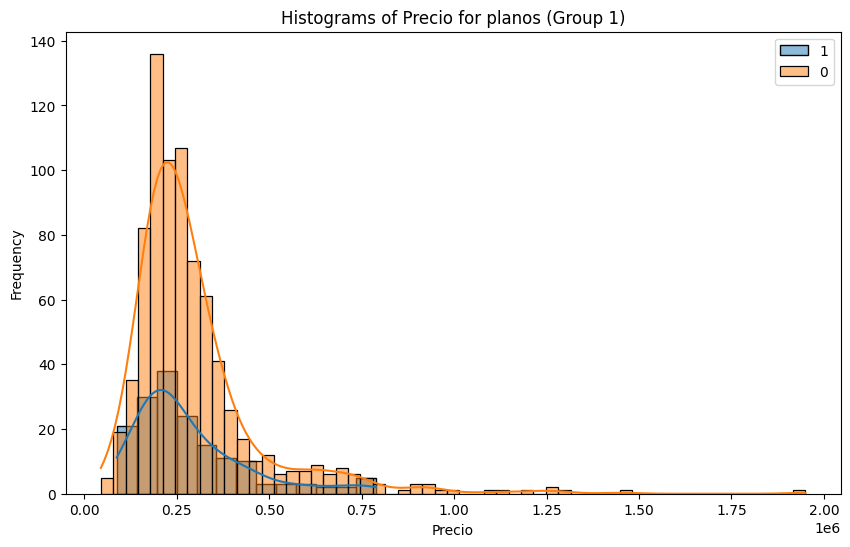

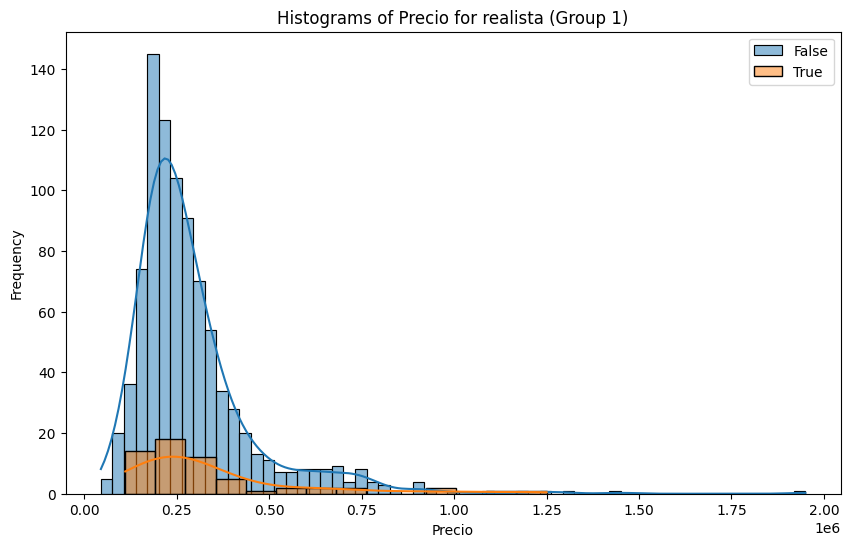

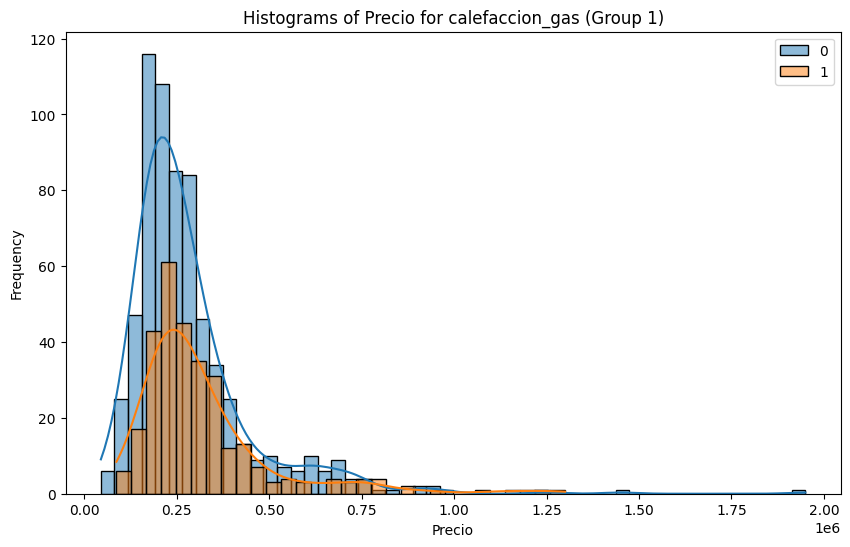

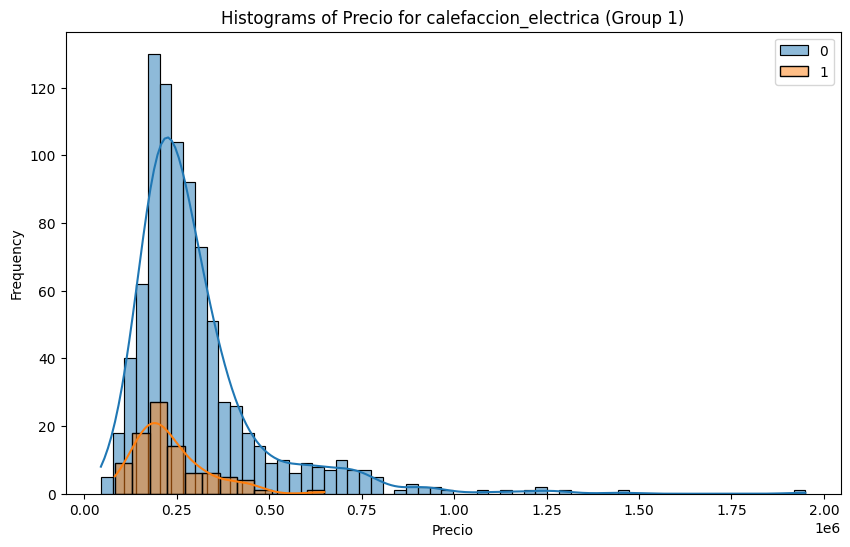

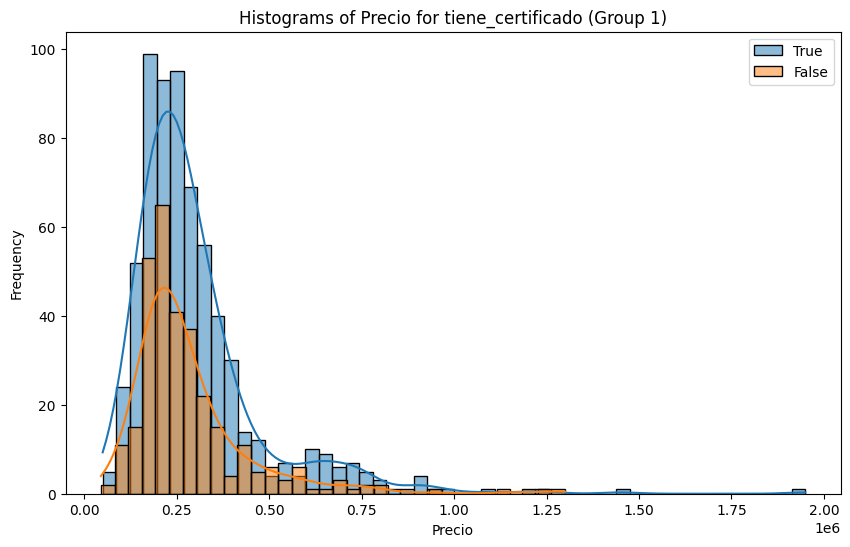

In [55]:
for col in (categoricas + binaria):
    if col in train_set.columns:
        bt.plot_grouped_histograms(train_set, cat_col=col, num_col='Precio', group_size = 8 )
    else:
        print(f'[WARN] {col} no está en df_plot.columns')

* **Precio por dormitorios:** los grupos más frecuentes son 3, 2, 1 y 4 dormitorios, y entre 1–3 se comportan de forma bastante similar. El de **4 dormitorios** sí se nota con un precio más alto.  
* **Baños:** lo más claro es 1, 2 y 3 baños; los histogramas se desplazan hacia la derecha a medida que aumenta la cantidad de baños.  
* **Aire acondicionado:** no vemos mucha diferencia en el comportamiento entre categorías (no tiene / independiente / centralizada). No se observan cruces especialmente evidentes.  
* **Calefacción:** se ve levemente un desplazamiento hacia la derecha (aumento del precio). Sin calefacción: menor precio; luego un poco más con calefacción independiente; y apenas un poco más con centralizada.  

* **Puntos de interés (servicios cercanos):**  
  1) **Transporte público:** lo interesante es que los que **no tienen transporte público cerca** se desplazan hacia la izquierda (más baratos). Si ordeno los histogramas de izquierda a derecha, se ve: **0, 3, 1, 2, 4/5**.  
  2) **Escuelas:** la mayoría tiene **5 alrededor**, por lo que domina el histograma y no se aprecia un patrón claro.  
  3) **Farmacias:** si bien la mayoría tiene **5**, los histogramas se cruzan mucho y no hay un orden definido. Por ejemplo, tener **1 farmacia** parece asociarse a mayor precio que tener **2 farmacias**.  
  4) **Hospitales:** de mucho interés; se entrecruzan todos los histogramas y se ve un desplazamiento hacia la derecha en los que tienen **5 hospitales alrededor**.  
  5) **Supermercados:** aunque la mayoría tiene **5**, se observa que los histogramas se entrecruzan bastante.  
  6) **Tiendas:** se entrelazan mejor que el resto.  
  7) **Bares:** los más corridos a la derecha son los que tienen **0, 1 y 2**.  
  8) **Restaurantes:** se ve, levemente, un desplazamiento hacia la izquierda en quienes no tienen restaurantes; los histogramas se entrecruzan.  

* **categoria_ord:** se ve que los outliers son de la **categoría 3**. La 3 y la 2 se entrecruzan en precios más altos; la 1 muestra precios más bajos. Luego aparecen más casos en 0 y 2, y finalmente en 3.  
* **clase_energetica_ord:** se observa claramente que los histogramas se entrelazan. Diría que los precios más altos serían los de la **clase 3**.  

**Target y variables binarias:**  
* **Ascensor:** de interés; con ascensor parecen levemente más caros.  
* **Planos:** podría sacarse; no se ven comportamientos distintos del target.  
* **Realista:** tampoco se ven cambios si tiene o no; se podría sacar.  
* **Calefacción gas:** no se ven comportamientos distintos; la sacaría.  
* **Calefacción eléctrica:** igual, sin comportamiento claro.  


En estos gráficos estuve mirando cómo se mueve el precio según distintas variables. En general, el target está muy sesgado a la derecha (cola larga con outliers), así que muchas categorías se pisan bastante y a veces cuesta ver diferencias claras solo con histogramas superpuestos. Aun así, hay algunas cosas que se repiten y otras que me dejan dudas (más por mezcla de zonas/tamaño de muestra que por falta de señal).

#### 1) Variables “de la vivienda” (más directas)

- **Dormitorios:** los grupos con más presencia son 1, 2, 3 y 4.  
  - Entre **1–3** se ven bastante parecidos y se superponen mucho.  
  - El que sí se nota más corrido a la derecha es **4 dormitorios**, que en promedio parece asociarse a precios más altos.  
  - Igual, esto puede estar muy influido por **superficie**: un piso con 4 dormitorios suele ser más grande, entonces parte del “efecto dormitorios” probablemente sea “efecto m²”.

- **Baños:** acá la relación es más clara.  
  - Con más baños el histograma se corre hacia la derecha.  
  - En especial, **1 vs 2 baños** muestra un cambio bastante evidente.  
  - Con **3 baños** también se ve un escalón hacia precios mayores (aunque con menos casos).

#### 2) Confort / instalaciones (señal leve, pero algo se ve)

- **Aire acondicionado:** no me queda una diferencia fuerte entre “no tiene / independiente / centralizada”.  
  - Los histogramas se cruzan bastante y el patrón no se marca tanto.  
  - Para mí es una variable que podría aportar algo en un modelo, pero a ojo no es de las más discriminantes en estos gráficos.

- **Calefacción:** acá sí se insinúa un gradiente.  
  - “Sin calefacción” tiende a estar más a la izquierda.  
  - Luego “independiente” y “centralizada” parecen moverse un poco hacia la derecha.  
  - No es un salto enorme, pero algo hay, aunque con bastante solapamiento.

#### 3) Variables de entorno (servicios cercanos)

Estas son las que más me cuesta interpretar en forma “causal”, porque probablemente estén capturando **centralidad/zona**. O sea, no es solo “más cosas cerca = más caro”, sino que “zonas más céntricas” suelen tener más servicios y a la vez ser más caras. Además, muchas variables están **capadas en 5** (la mayoría queda en “5”), y eso también hace que visualmente una categoría “se coma” a las otras.

- **Transporte público (tp_cnt):** esto sí me pareció interesante.  
  - Cuando es **0**, el precio se desplaza más a la izquierda (más barato).  
  - A medida que sube el conteo se ve más mezcla, y el orden fino (1 vs 2 vs 3 vs 4/5) no lo tomaría como conclusión fuerte solo por estos histogramas.

- **Escuelas (esc_cnt):** casi todo está en **5**, entonces no me permite diferenciar bien; parece una variable con poca capacidad discriminativa así como está.

- **Farmacias (fca_cnt):** hay mucho cruce y no veo un orden claro.  
  - Por ejemplo, tener 1 farmacia parece más caro que 2 en algunos rangos, lo cual me sugiere que acá hay bastante ruido o confusión por zona.

- **Hospitales (hosp_cnt):** me llamó la atención que el grupo con valores altos (sobre todo **5**) parece más corrido a la derecha.  
  - Puede ser señal real, pero también puede ser simplemente un proxy de barrios más céntricos o mejor conectados.

- **Supermercados / tiendas / restaurantes:** se entrecruzan bastante.  
  - En restaurantes sí se ve algo como que “0” podría estar un poco más a la izquierda, pero no es súper limpio.

- **Bares:** acá me sorprendió que los que tienen **0–2** parezcan más a la derecha.  
  - Esto puede ser real (zonas residenciales premium con menos oferta) o puede ser un artefacto por tamaños muestrales / mezcla por distrito, así que lo dejaría como “dato a confirmar”.

#### 4) Variables ordinales / categorizaciones

- **categoria_ord:** se ven outliers sobre todo en categoría 3.  
  - También se cruzan bastante 2 y 3 en precios altos, y 1 parece tender a precios más bajos.  
  - Pero no lo tomaría literal como “orden” si la codificación no representa una escala real.

- **clase_energetica_ord:** los histogramas se superponen mucho.  
  - Si tuviera que decir algo, es que no aparece un patrón fuerte.  
  - Los precios altos parecen aparecer en varias clases, y el grupo “3” se ve con algunos valores altos, pero no es una relación limpia.

#### 5) Binarias contra el target

- **Ascensor:** es de las más interesantes.  
  - Con ascensor parece haber un corrimiento leve a mayor precio.  
  - Igual, sospecho que se vería mejor si lo cruzo con planta (porque en pisos altos el ascensor pesa mucho más).

- **Planos:** no veo una diferencia clara; en estos gráficos no parece aportar demasiado.

- **Realista:** no noto cambio relevante.

- **Calefacción gas / eléctrica:** en estos histogramas no se ve un comportamiento distinto claro.  
  - Si tuviera que simplificar el set de variables, estas serían candidatas a recodificar o incluso quitar (dependiendo de si aportan algo en validación).

### Conclusión general

En resumen, lo que más consistente aparece es lo “estructural” (**baños y dormitorios**) y luego algunas cosas de confort (**calefacción y algo de ascensor**). Las variables de entorno son más difíciles de leer solo con histogramas porque se mezclan con la zona y muchas están dominadas por el valor 5, así que más que descartarlas por esto, lo que haría es confirmarlas con una **tabla de medianas por categoría** (y idealmente mirando **log(precio)** o **precio/m²**) para no dejarme llevar por el efecto de outliers y tamaños muestrales.

### Matriz de correlacion

In [56]:
numericas_con_precio = numericas + ['Precio']

print('Correlacion de pearson:')
corr = train_set[numericas_con_precio].corr('pearson')
np.abs(corr[target]).sort_values(ascending = False)

Correlacion de pearson:


Precio                   1.000000
latitud                  0.236850
fotografias              0.208418
hosp_min_dist_m          0.184861
resto_min_dist_m         0.134090
emisiones_energeticas    0.131637
planta                   0.130269
tp_min_dist_m            0.129626
bar_min_dist_m           0.120906
tda_min_dist_m           0.114536
super_min_dist_m         0.109770
fca_min_dist_m           0.106844
eficiencia_energetica    0.073144
esc_min_dist_m           0.071121
ano_construccion         0.063735
superficie_m2            0.040431
longitud                 0.034027
Name: Precio, dtype: float64

In [57]:
print('Correlacion de spearman:')
corr_spe = train_set[numericas_con_precio].corr('spearman')
np.abs(corr_spe[target]).sort_values(ascending = False)

Correlacion de spearman:


Precio                   1.000000
superficie_m2            0.390307
latitud                  0.350087
resto_min_dist_m         0.262916
emisiones_energeticas    0.210247
fca_min_dist_m           0.205821
tda_min_dist_m           0.197787
tp_min_dist_m            0.193888
fotografias              0.193004
hosp_min_dist_m          0.190643
bar_min_dist_m           0.155367
super_min_dist_m         0.152460
planta                   0.151243
eficiencia_energetica    0.118471
esc_min_dist_m           0.115404
longitud                 0.068462
ano_construccion         0.024694
Name: Precio, dtype: float64

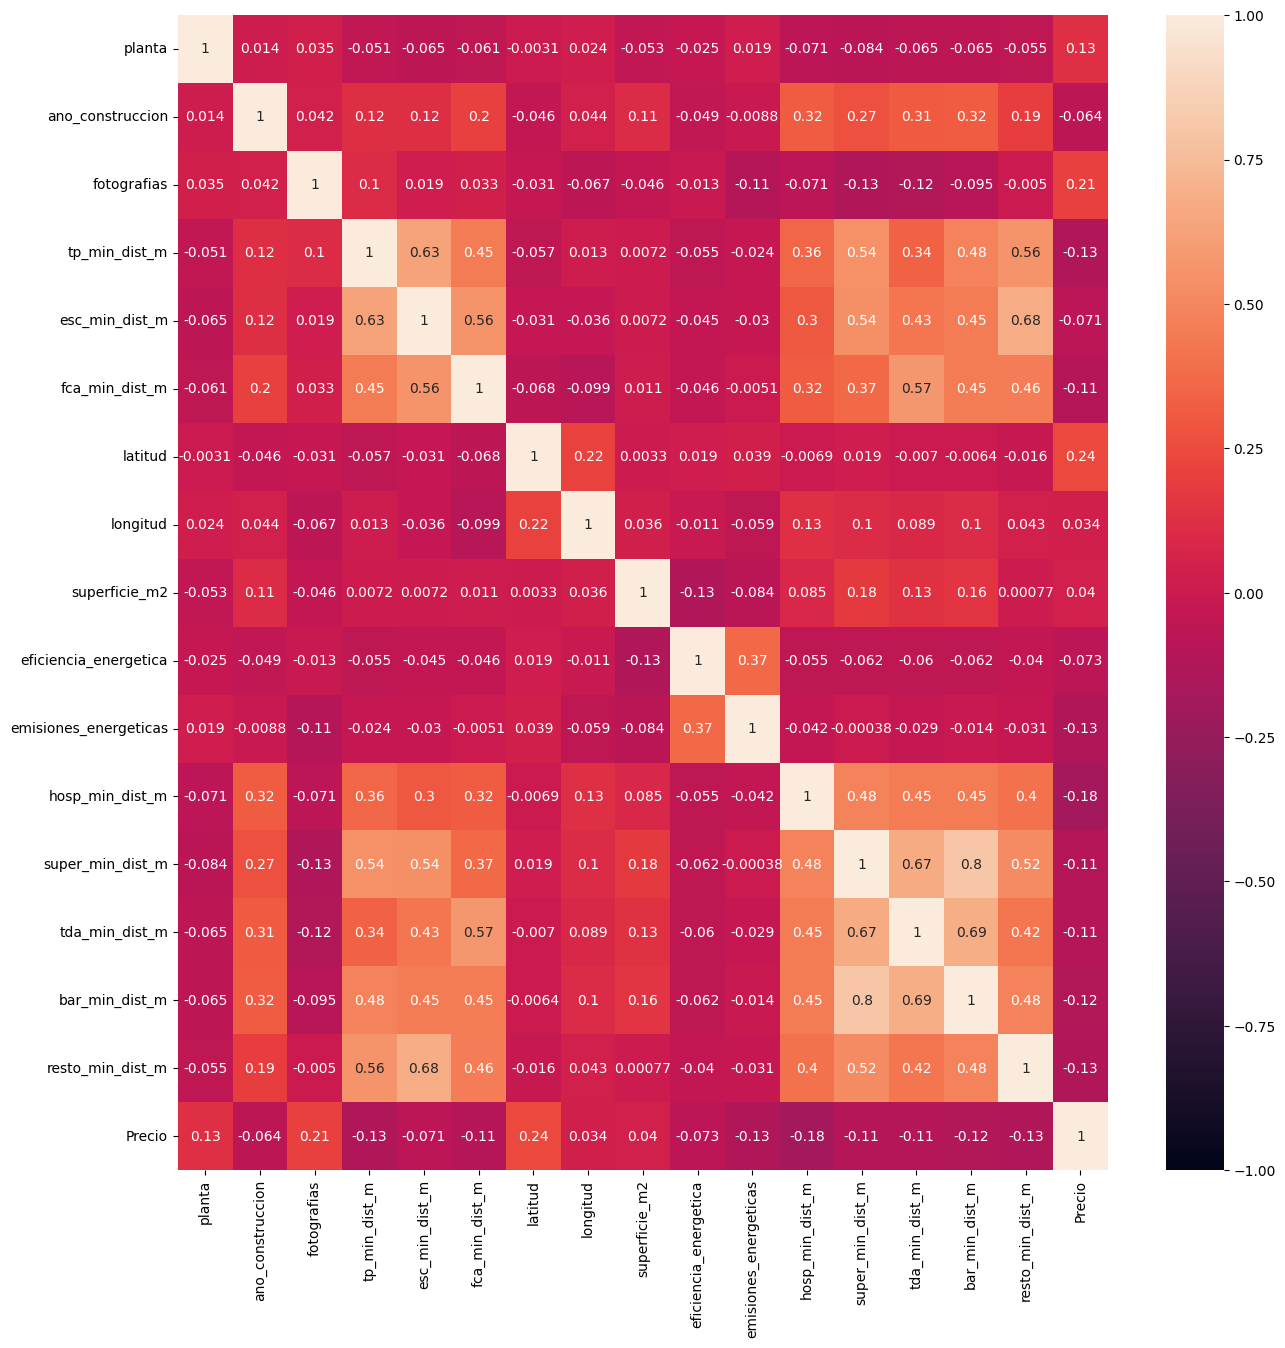

In [58]:
plt.figure(figsize = (15,15))
sns.heatmap(corr, annot= True, vmin=-1)
plt.show()

### 1) Correlación absoluta con el target (Precio):
A partir del ranking de correlaciones absolutas con **Precio**, se observa que las correlaciones son, en general, **bajas** (las más altas rondan aproximadamente **0.22** y el resto cae por debajo). Esto sugiere que **no hay relaciones lineales fuertes** entre el precio y estas variables numéricas consideradas de forma individual.

Esto **no implica** que las variables “no sirvan”, sino que:
- el efecto puede ser **no lineal**,
- puede depender de **interacciones** (por ejemplo, superficie × zona × planta × servicios),
- y además el precio suele presentar **cola derecha y outliers**, lo que puede hacer que la correlación de Pearson subestime patrones reales.

Nota: en variables tipo `*_min_dist_m`, si “más cerca = más caro”, lo esperable es una **correlación negativa** con el precio (menor distancia, mayor precio). En el ranking por valor absoluto vemos “fuerza” de asociación, pero el **signo** se interpreta mirando la matriz completa.

En resumen, este análisis univariado lineal sugiere que el precio no está explicado por una sola variable numérica, sino por una combinación de factores. Por eso es esperable que modelos capaces de capturar **no linealidades e interacciones** (árboles/boosting) rindan mejor.

---

### 2) Matriz de correlación:
En la matriz de correlación, el objetivo principal es detectar **bloques de variables que estén midiendo algo parecido** (redundancia / multicolinealidad), más que enfocarse en el precio.

Puntos relevantes:
- **Variables energéticas:** `eficiencia_energetica` y `emisiones_energeticas` muestran una correlación moderada-alta (aprox. **0.56**), lo que indica información parcialmente redundante.
- **Distancias a servicios:** varias variables de distancia a servicios cercanos (`super_min_dist_m`, `tda_min_dist_m`, `bar_min_dist_m`, `resto_min_dist_m`, etc.) presentan correlaciones moderadas entre sí (aprox. **0.45–0.52**). Esto suele reflejar un factor común tipo “centralidad/densidad urbana”.
- **Otras asociaciones esperables:** por ejemplo, `tp_min_dist_m` y `esc_min_dist_m` muestran correlaciones moderadas (aprox. **0.45**), posiblemente también ligadas a la zona.

Conclusión práctica: no parece haber colinealidad extrema (tipo >0.90), pero sí **redundancia moderada** en algunos bloques lógicos. Dependiendo del modelo, se puede:
- dejar todas (boosting suele tolerarlo),
- seleccionar 1–2 por bloque,
- o construir un índice combinado de “accesibilidad/centralidad”.

---

### Si aplicamos logaritmo al target

In [59]:
train_set['Precio_log'] = np.log(train_set['Precio'])
numericas_con_precio_log = numericas + ['Precio_log']

print('Correlacion de pearson con logaritmo:')
corr = train_set[numericas_con_precio_log].corr('pearson')
np.abs(corr['Precio_log']).sort_values(ascending = False)

Correlacion de pearson con logaritmo:


Precio_log               1.000000
latitud                  0.309181
hosp_min_dist_m          0.239813
tp_min_dist_m            0.226473
resto_min_dist_m         0.193737
fotografias              0.184137
planta                   0.177755
fca_min_dist_m           0.151147
bar_min_dist_m           0.148178
super_min_dist_m         0.147697
esc_min_dist_m           0.128050
tda_min_dist_m           0.127260
emisiones_energeticas    0.122830
longitud                 0.090261
eficiencia_energetica    0.061423
superficie_m2            0.038350
ano_construccion         0.033219
Name: Precio_log, dtype: float64

In [60]:
print('Correlacion de spearman con logaritmo:')
corr_spe = train_set[numericas_con_precio_log].corr('spearman')
np.abs(corr_spe['Precio_log']).sort_values(ascending = False)

Correlacion de spearman con logaritmo:


Precio_log               1.000000
superficie_m2            0.390307
latitud                  0.350087
resto_min_dist_m         0.262916
emisiones_energeticas    0.210247
fca_min_dist_m           0.205821
tda_min_dist_m           0.197787
tp_min_dist_m            0.193888
fotografias              0.193004
hosp_min_dist_m          0.190643
bar_min_dist_m           0.155367
super_min_dist_m         0.152460
planta                   0.151243
eficiencia_energetica    0.118471
esc_min_dist_m           0.115404
longitud                 0.068462
ano_construccion         0.024694
Name: Precio_log, dtype: float64

### Comparación de modelos

In [61]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop',
).set_output(transform='pandas')

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),

    ],
    remainder='drop'
).set_output(transform='pandas')

preprocess.fit_transform(X_train_limpio).head()

,num__latitud,num__longitud,num__dormitorios,num__superficie_m2,num__baños,num__planta,num__ascensor,num__ano_construccion,num__planos,num__fotografias,num__eficiencia_energetica,num__emisiones_energeticas,num__tp_cnt,num__tp_min_dist_m,num__esc_cnt,num__esc_min_dist_m,num__fca_cnt,num__fca_min_dist_m,num__hosp_cnt,num__hosp_min_dist_m,num__super_cnt,num__super_min_dist_m,num__tda_cnt,num__tda_min_dist_m,num__bar_cnt,num__bar_min_dist_m,num__resto_cnt,num__resto_min_dist_m,num__calefaccion_gas,num__calefaccion_electrica,num__categoria_ord,num__clase_energetica_ord,cat__cluster_A,cat__cluster_B,cat__cluster_C,cat__cluster_D,cat__cluster_E,cat__aire_acondicionado_Centralizada,cat__aire_acondicionado_Independiente,cat__aire_acondicionado_NO,cat__calefaccion_Independiente,cat__calefaccion_NO,cat__calefaccion_centralizada
1055,40.489602,-3.886053,2.0,120.0,1.0,3.0,1.0,1990.0,1.0,29.0,240.6,50.4,3.0,140.0,5.0,320.0,5.0,770.0,1.0,2100.0,5.0,720.0,5.0,710.0,5.0,180.0,5.0,610.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
666,40.446802,-3.703233,2.0,42.0,1.0,2.0,0.0,1925.0,0.0,22.0,162.0,34.0,5.0,60.0,5.0,150.0,5.0,50.0,5.0,380.0,5.0,110.0,5.0,40.0,5.0,100.0,5.0,50.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1014,40.494502,-3.693703,4.0,88.0,2.0,5.0,1.0,1979.0,0.0,24.0,294.0,61.0,5.0,40.0,5.0,60.0,5.0,70.0,5.0,890.0,5.0,220.0,5.0,340.0,5.0,330.0,5.0,310.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
650,40.484702,-3.359223,2.0,80.0,1.0,0.0,0.0,1965.0,0.0,24.0,222.0,49.7,4.0,90.0,5.0,60.0,5.0,150.0,5.0,740.0,5.0,170.0,5.0,90.0,5.0,150.0,5.0,150.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
899,40.435002,-3.706983,5.0,152.0,2.0,5.0,0.0,1940.0,0.0,29.0,174.0,36.0,5.0,130.0,5.0,110.0,5.0,100.0,5.0,400.0,5.0,40.0,5.0,190.0,5.0,100.0,5.0,30.0,1.0,0.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [62]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [63]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
4,CatBoostRegressor,1.673687e-01
3,LGBMRegressor,1.700646e-01
2,XGBRegressor,1.829833e-01
1,RandomForest,1.976690e-01
0,DecisionTree,2.486918e-01
7,knn_reg_5,2.639182e-01
6,knn_reg_3,2.684182e-01
5,lr_reg,9.356934e+14


En la comparación inicial, el mejor desempeño lo obtuvo CatBoostRegressor con un RMSE medio de aproximadamente 85.000 €, seguido por XGBoost (~94.000 €), Random Forest (~98.000 €) y LightGBM (~102.000 €); en cambio, KNN quedó bastante por detrás (~136–139k) y la regresión lineal fue claramente la peor (~340k), lo que sugiere que la relación entre las variables y el precio no es lineal y que los modelos basados en árboles y boosting capturan mejor interacciones y no linealidades.   

Al analizar la distribución del precio objetivo, se observa un mínimo cercano a 44.900 €, una mediana alrededor de 250.000 €, un percentil 75 de aproximadamente 338.000 € y un máximo de 1.950.000 €, muy extremo respecto del resto, lo que indica una distribución asimétrica con cola derecha y presencia de outliers(como vimos en el grafico del target anteriormente). En este contexto, un RMSE de ~85.000 € puede parecer relativamente “aceptable” en el rango central (aprox. 250–338k), pero resulta muy grande en términos relativos para viviendas baratas (por ejemplo, cerca de 45k implica errores comparables o incluso superiores al propio precio), por lo que además de RMSE conviene incorporar métricas de error relativo (como MAPE o MAE/mediana) y revisar si los modelos fallan de forma desproporcionada en los extremos (viviendas muy caras o muy baratas).

### Ajuste de hiperparametros

In [64]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-01 20:43:12,654] A new study created in memory with name: no-name-897d6c5c-e007-4ecd-b55a-7a1702059397
[I 2026-03-01 20:43:13,424] Trial 0 finished with value: -0.16372330784797667 and parameters: {'model__n_estimators': 670, 'model__learning_rate': 0.06258931260540056, 'model__max_depth': 5, 'model__min_child_weight': 3, 'model__subsample': 0.7131867558470733, 'model__colsample_bytree': 0.8326200939531396, 'model__reg_alpha': 0.21263412181074162, 'model__reg_lambda': 3.752576668892816}. Best is trial 0 with value: -0.16372330784797667.
[I 2026-03-01 20:43:15,025] Trial 1 finished with value: -0.1690104603767395 and parameters: {'model__n_estimators': 816, 'model__learning_rate': 0.06376978533998558, 'model__max_depth': 8, 'model__min_child_weight': 5, 'model__subsample': 0.9092883207817625, 'model__colsample_bytree': 0.7704277851515097, 'model__reg_alpha': 0.0030829689806472506, 'model__reg_lambda': 3.499614891455201}. Best is trial 0 with value: -0.16372330784797667.
[I 20

{'model__n_estimators': 1008,
 'model__learning_rate': 0.0495209179347069,
 'model__max_depth': 5,
 'model__min_child_weight': 4,
 'model__subsample': 0.7681389135969544,
 'model__colsample_bytree': 0.9429281351248227,
 'model__reg_alpha': 0.09978692758012622,
 'model__reg_lambda': 1.0125623366097218}

In [65]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...0015FA9701580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [66]:
mean_absolute_percentage_error(y_test, pipe_xgb_log.predict(X_test))

0.1568930447101593

XGBoost: 0.1475 -> 1m42s

In [67]:
def objective_lgb(trial):
    
    lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
    pipe_lgb = Pipeline(steps=[('preprocess', preprocess), ('model', lgb_base)])
    
    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 12),
        'model__num_leaves': trial.suggest_int('model__num_leaves', 20, 100),
        'model__min_child_samples': trial.suggest_int('model__min_child_samples', 5, 50),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_lgb.set_params(**params)
    
    pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_lgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_lgb = create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100)

best_params_lgb = study_lgb.best_params
best_params_lgb

[I 2026-03-01 20:45:24,660] A new study created in memory with name: no-name-b2ba4c19-ff5f-46d2-80b9-e6be8e6956a3
[I 2026-03-01 20:45:26,168] Trial 0 finished with value: -0.17097352709152575 and parameters: {'model__n_estimators': 919, 'model__learning_rate': 0.08207800157552488, 'model__max_depth': 10, 'model__num_leaves': 75, 'model__min_child_samples': 41, 'model__subsample': 0.861362179487094, 'model__colsample_bytree': 0.9708039244959566, 'model__reg_alpha': 0.11666559038553664, 'model__reg_lambda': 3.601125271906019}. Best is trial 0 with value: -0.17097352709152575.
[I 2026-03-01 20:45:27,767] Trial 1 finished with value: -0.16595802913791782 and parameters: {'model__n_estimators': 1099, 'model__learning_rate': 0.010877695777878426, 'model__max_depth': 5, 'model__num_leaves': 93, 'model__min_child_samples': 19, 'model__subsample': 0.7375244448996207, 'model__colsample_bytree': 0.7492616401381867, 'model__reg_alpha': 0.0037254223348493275, 'model__reg_lambda': 3.735923536071905}

{'model__n_estimators': 903,
 'model__learning_rate': 0.02040410477900504,
 'model__max_depth': 8,
 'model__num_leaves': 67,
 'model__min_child_samples': 21,
 'model__subsample': 0.8556703127856772,
 'model__colsample_bytree': 0.7876366772992569,
 'model__reg_alpha': 0.00120005695873683,
 'model__reg_lambda': 3.03041078862725}

In [68]:
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', lgb_base)])

pipe_lgb.set_params(**best_params_lgb)

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...rbosity=-1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...0015FA9701580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [69]:
mean_absolute_percentage_error(y_test, pipe_lgb_log.predict(X_test))

0.15732536871707015

LightGBoost: 0.1549 -> 4m09s

In [70]:
def objective_cat(trial):

    cat_base = CatBoostRegressor(random_state=42, loss_function="MAPE",verbose=False,)
    pipe_cat = Pipeline(steps=[('preprocess', preprocess), ("model", cat_base)])

    params = {
        "model__depth": trial.suggest_int("model__depth", 6, 10),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__iterations": trial.suggest_int("model__iterations", 500, 1200),
        "model__l2_leaf_reg": trial.suggest_float("model__l2_leaf_reg", 1.0, 10.0),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__random_strength": trial.suggest_float("model__random_strength", 0.5, 2.0),
    }
    
    pipe_cat.set_params(**params)

    pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_cat_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_cat = create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=100)

best_params_cat = study_cat.best_params
best_params_cat

[I 2026-03-01 20:48:43,020] A new study created in memory with name: no-name-712176d8-6e5e-40a4-ab00-cd1574473a54
[I 2026-03-01 20:48:50,199] Trial 0 finished with value: -0.17257513463201088 and parameters: {'model__depth': 7, 'model__learning_rate': 0.02846600834157631, 'model__iterations': 1133, 'model__l2_leaf_reg': 1.8769015609167292, 'model__subsample': 0.7472204295226454, 'model__random_strength': 1.7953358590329567}. Best is trial 0 with value: -0.17257513463201088.
[I 2026-03-01 20:50:06,156] Trial 1 finished with value: -0.19282711248604162 and parameters: {'model__depth': 10, 'model__learning_rate': 0.06671881475484302, 'model__iterations': 925, 'model__l2_leaf_reg': 6.233531019550492, 'model__subsample': 0.8947078138442072, 'model__random_strength': 1.128453453683003}. Best is trial 0 with value: -0.17257513463201088.
[I 2026-03-01 20:50:08,998] Trial 2 finished with value: -0.17034839556409415 and parameters: {'model__depth': 6, 'model__learning_rate': 0.07375824726022395,

{'model__depth': 6,
 'model__learning_rate': 0.04678419869904439,
 'model__iterations': 1068,
 'model__l2_leaf_reg': 7.450018518195684,
 'model__subsample': 0.7295451813457858,
 'model__random_strength': 1.8696383285859595}

In [71]:
cat_base = CatBoostRegressor(random_state=42, loss_function='MAPE', verbose=False)
pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', cat_base)])

pipe_cat.set_params(**best_params_cat)

pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)

pipe_cat_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...bose=False))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...0015FA9701580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [72]:
mean_absolute_percentage_error(y_test, pipe_cat_log.predict(X_test))

0.1600987162065712

CatBoost: 0.1594 -> 11m57s

Parece que XGBoost es el que mejor resultados nos da, ahora toca entrenar el modelo completo y performarlo, pero primero hagamos un estudio de rendimiento para obtener un modelo más ligero con una seleccion de features inteligente:

In [73]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

start = time()
pipe_xgb_log.fit(X_train_limpio, y_train)
train_time = [(time() - start)]

score = [cross_val_score(pipe_xgb_log, X_train_limpio, y_train, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean()]

pd.DataFrame({'score': score, 'time': train_time}).sort_values('score')

,score,time
0,-0.161368,0.837302


In [74]:
def performar_tiempo(X, y, col=None):

    if col:
        X = X.drop(columns=col)

    lista_col = []
    train_time = []
    score = []

    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])
    pipe_xgb.set_params(**best_params_xgb)
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

    for col in X.columns:

        print(f'Ocultando {col}...', end='\t')
        lista_col.append(col)
        X_menos = X.drop(columns=col)

        start = time()
        pipe_xgb_log.fit(X_menos, y)
        train_time.append(time() - start)

        score.append(cross_val_score(pipe_xgb_log, X_menos, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())
    
    resultados = pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).set_index('columna').sort_values('score', ascending=False).iloc[0]

    if len(X.columns) > 2:
        print(f'Eliminamos {resultados.name}...')
        resultados = pd.concat([resultados, performar_tiempo(X, y, col=resultados.name)], axis=1)

    return resultados

resultados_funcion = performar_tiempo(X_train_limpio, y_train)
resultados_funcion

Ocultando latitud...	Ocultando longitud...	Ocultando cluster...	Ocultando dormitorios...	Ocultando superficie_m2...	Ocultando baños...	Ocultando planta...	Ocultando aire_acondicionado...	Ocultando ascensor...	Ocultando calefaccion...	Ocultando ano_construccion...	Ocultando planos...	Ocultando realista...	Ocultando fotografias...	Ocultando eficiencia_energetica...	Ocultando emisiones_energeticas...	Ocultando tp_cnt...	Ocultando tp_min_dist_m...	Ocultando esc_cnt...	Ocultando esc_min_dist_m...	Ocultando fca_cnt...	Ocultando fca_min_dist_m...	Ocultando hosp_cnt...	Ocultando hosp_min_dist_m...	Ocultando super_cnt...	Ocultando super_min_dist_m...	Ocultando tda_cnt...	Ocultando tda_min_dist_m...	Ocultando bar_cnt...	Ocultando bar_min_dist_m...	Ocultando resto_cnt...	Ocultando resto_min_dist_m...	Ocultando calefaccion_gas...	Ocultando calefaccion_electrica...	Ocultando categoria_ord...	Ocultando clase_energetica_ord...	Ocultando tiene_certificado...	Eliminamos super_min_dist_m...
Ocultando la

,super_min_dist_m,tiene_certificado,realista,fotografias,fca_min_dist_m,calefaccion_electrica,resto_cnt,dormitorios,resto_min_dist_m,emisiones_energeticas,planos,tda_cnt,categoria_ord,clase_energetica_ord,super_cnt,tp_cnt,calefaccion_gas,cluster,fca_cnt,eficiencia_energetica,planta,aire_acondicionado,esc_cnt,bar_cnt,ascensor,bar_min_dist_m,tda_min_dist_m,esc_min_dist_m,hosp_min_dist_m,baños,calefaccion,tp_min_dist_m,ano_construccion,hosp_cnt,longitud,superficie_m2
score,-0.159900,-0.159900,-0.159900,-0.160149,-0.159803,-0.159804,-0.157749,-0.157659,-0.15895,-0.158141,-0.156714,-0.156407,-0.157978,-0.157670,-0.157987,-0.158088,-0.157505,-0.157873,-0.158376,-0.159566,-0.159184,-0.160651,-0.161930,-0.160119,-0.161113,-0.161500,-0.163345,-0.164343,-0.164210,-0.164667,-0.171091,-0.175875,-0.176790,-0.180688,-0.261999,-0.331660
time,0.813533,0.877328,0.742716,0.649509,0.648640,0.641180,0.663629,0.614809,0.61745,0.616631,0.618738,0.597036,0.589841,0.593129,0.624942,0.618752,0.630384,0.592126,0.609021,0.598349,0.590156,0.492844,0.505462,0.564713,0.555911,0.543629,0.527328,0.545401,0.500962,0.445969,0.411829,0.423851,0.394848,0.385682,0.348982,0.360971


In [75]:
resultados_funcion.T.reset_index().reset_index()

,level_0,index,score,time
0,0,super_min_dist_m,-0.159900,0.813533
1,1,tiene_certificado,-0.159900,0.877328
2,2,realista,-0.159900,0.742716
3,3,fotografias,-0.160149,0.649509
4,4,fca_min_dist_m,-0.159803,0.648640
5,5,calefaccion_electrica,-0.159804,0.641180
6,6,resto_cnt,-0.157749,0.663629
7,7,dormitorios,-0.157659,0.614809
8,8,resto_min_dist_m,-0.158950,0.617450
9,9,emisiones_energeticas,-0.158141,0.616631


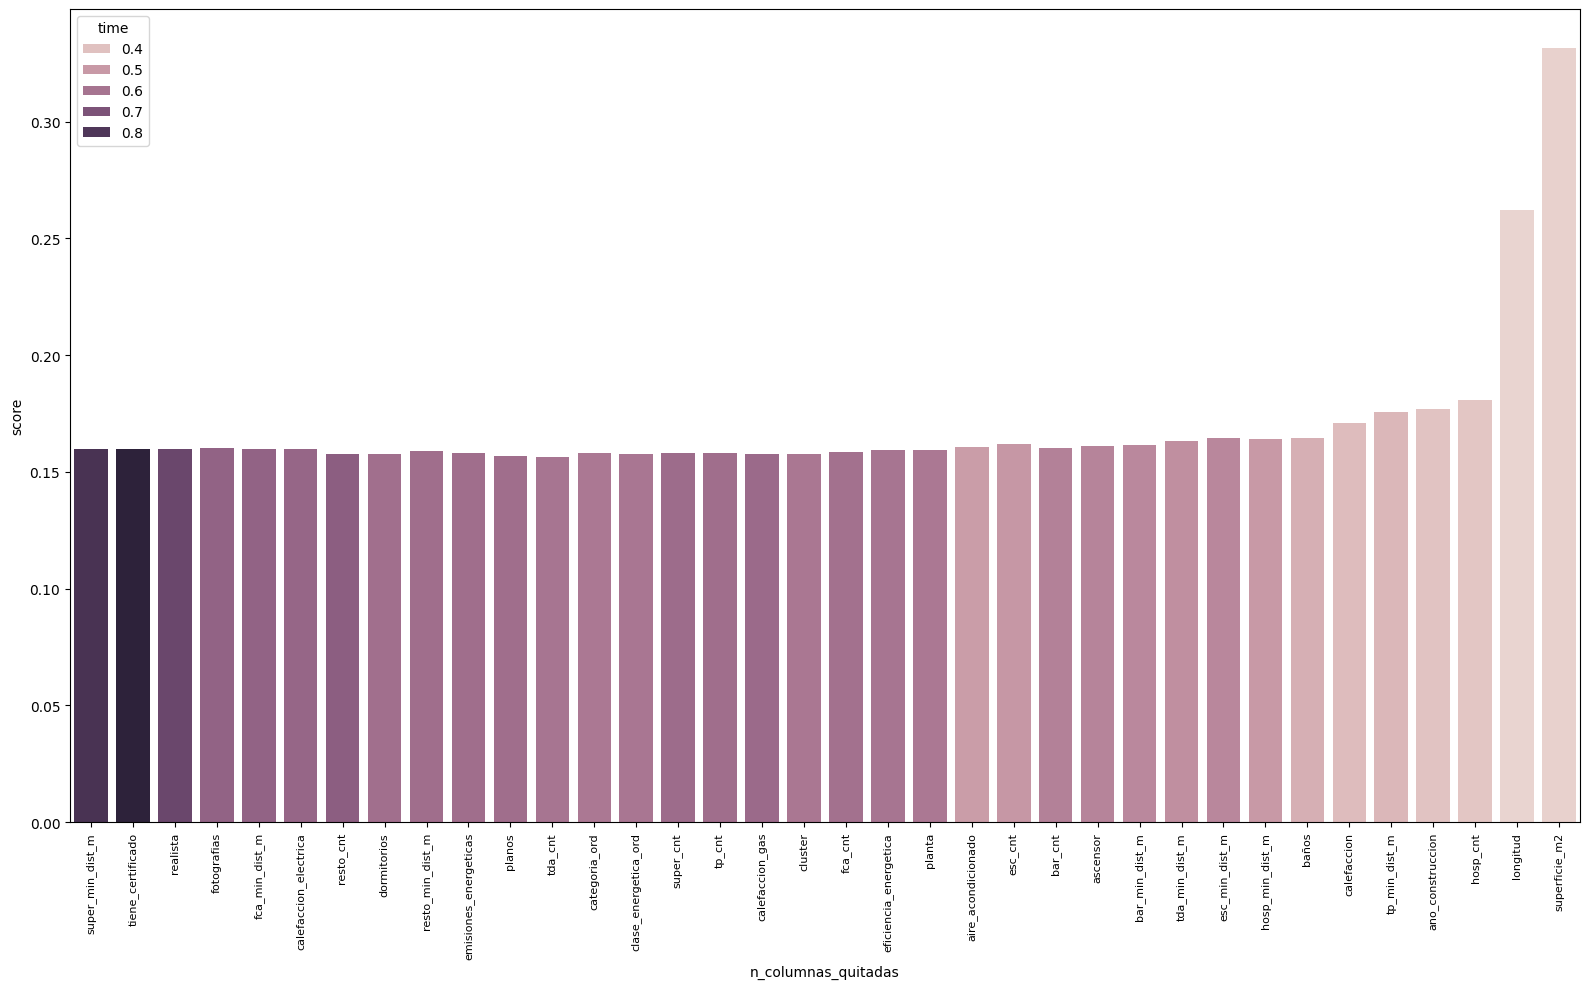

In [76]:
res = resultados_funcion.T.reset_index().reset_index()

res['score'] = res['score'] * -1
res['level_0'] = res['level_0'] + 1

res = res.rename(columns={'level_0': 'n_columnas_quitadas'})

# res['level_0_bin'] = pd.cut(res['level_0'], bins=3)

# sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

plt.figure(figsize=(16, 10))
ax = sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['index'], rotation=90)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()

In [ ]:
columnas_a_quitar = resultados_funcion.T[:28].index.to_list()

columnas_a_quitar

['super_min_dist_m',
 'tiene_certificado',
 'realista',
 'fotografias',
 'fca_min_dist_m',
 'calefaccion_electrica',
 'resto_cnt',
 'dormitorios',
 'resto_min_dist_m',
 'emisiones_energeticas',
 'planos',
 'tda_cnt',
 'categoria_ord',
 'clase_energetica_ord',
 'super_cnt',
 'tp_cnt',
 'calefaccion_gas',
 'cluster',
 'fca_cnt',
 'eficiencia_energetica',
 'planta',
 'aire_acondicionado',
 'esc_cnt',
 'bar_cnt',
 'ascensor',
 'bar_min_dist_m',
 'tda_min_dist_m',
 'esc_min_dist_m']

In [87]:
optimizacion =  ColumnTransformer(
    transformers=[
        ('drop', 'drop',  ['super_min_dist_m',
                           'tiene_certificado',
                           'realista',
                           'fotografias',
                           'fca_min_dist_m',
                           'calefaccion_electrica',
                           'resto_cnt',
                           'dormitorios',
                           'resto_min_dist_m',
                           'emisiones_energeticas',
                           'planos',
                           'tda_cnt',
                           'categoria_ord',
                           'clase_energetica_ord',
                           'super_cnt',
                           'tp_cnt',
                           'calefaccion_gas',
                           'cluster',
                           'fca_cnt',
                           'eficiencia_energetica',
                           'planta',
                           'aire_acondicionado',
                           'esc_cnt',
                           'bar_cnt',
                           'ascensor',
                           'bar_min_dist_m',
                           'tda_min_dist_m',
                           'esc_min_dist_m']),
    ],
    remainder='passthrough',
).set_output(transform='pandas')

pipe_xgb = Pipeline(steps=[('optimizacion', optimizacion), ('preprocess', preprocess)])

pipe_xgb.fit_transform(X_train_limpio)

,num__remainder__latitud,num__remainder__longitud,num__remainder__superficie_m2,num__remainder__baños,num__remainder__ano_construccion,num__remainder__tp_min_dist_m,num__remainder__hosp_cnt,num__remainder__hosp_min_dist_m,cat__remainder__calefaccion_Independiente,cat__remainder__calefaccion_NO,cat__remainder__calefaccion_centralizada
1055,40.489602,-3.886053,120.0,1.0,1990.0,140.0,1.0,2100.0,1.0,0.0,0.0
666,40.446802,-3.703233,42.0,1.0,1925.0,60.0,5.0,380.0,0.0,1.0,0.0
1014,40.494502,-3.693703,88.0,2.0,1979.0,40.0,5.0,890.0,0.0,1.0,0.0
650,40.484702,-3.359223,80.0,1.0,1965.0,90.0,5.0,740.0,1.0,0.0,0.0
899,40.435002,-3.706983,152.0,2.0,1940.0,130.0,5.0,400.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
1044,40.416702,-3.541433,69.0,1.0,1972.0,170.0,3.0,730.0,1.0,0.0,0.0
1095,40.456002,-3.702163,45.0,1.0,1940.0,30.0,5.0,1100.0,0.0,1.0,0.0
1130,40.431202,-3.618383,47.0,1.0,1960.0,180.0,4.0,1000.0,1.0,0.0,0.0
860,40.355902,-3.781522,46.0,1.0,1975.0,60.0,3.0,980.0,0.0,1.0,0.0


In [80]:
columnas_a_quitar = resultados_funcion.T[:28].index.to_list()

X_train_opt = X_train_limpio.drop(columns=columnas_a_quitar)

X_train_opt

,latitud,longitud,superficie_m2,baños,calefaccion,ano_construccion,tp_min_dist_m,hosp_cnt,hosp_min_dist_m
1055,40.489602,-3.886053,120.0,1.0,Independiente,1990,140.0,1,2100.0
666,40.446802,-3.703233,42.0,1.0,NO,1925,60.0,5,380.0
1014,40.494502,-3.693703,88.0,2.0,NO,1979,40.0,5,890.0
650,40.484702,-3.359223,80.0,1.0,Independiente,1965,90.0,5,740.0
899,40.435002,-3.706983,152.0,2.0,centralizada,1940,130.0,5,400.0
...,...,...,...,...,...,...,...,...,...
1044,40.416702,-3.541433,69.0,1.0,Independiente,1972,170.0,3,730.0
1095,40.456002,-3.702163,45.0,1.0,NO,1940,30.0,5,1100.0
1130,40.431202,-3.618383,47.0,1.0,Independiente,1960,180.0,4,1000.0
860,40.355902,-3.781522,46.0,NaN,NO,1975,60.0,3,980.0


In [90]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_opt,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb_opt = study_xgb.best_params
best_params_xgb_opt

[I 2026-03-02 20:38:57,449] A new study created in memory with name: no-name-eacaaf4a-d66b-4215-a874-0468a4898b9e
[I 2026-03-02 20:38:59,397] Trial 0 finished with value: -0.1642497271299362 and parameters: {'model__n_estimators': 578, 'model__learning_rate': 0.05414350026442672, 'model__max_depth': 4, 'model__min_child_weight': 4, 'model__subsample': 0.7780764640865556, 'model__colsample_bytree': 0.7860147503573522, 'model__reg_alpha': 0.011512750587023573, 'model__reg_lambda': 2.8837031143340313}. Best is trial 0 with value: -0.1642497271299362.
[I 2026-03-02 20:39:01,423] Trial 1 finished with value: -0.16402870118618013 and parameters: {'model__n_estimators': 828, 'model__learning_rate': 0.0133630834086716, 'model__max_depth': 5, 'model__min_child_weight': 4, 'model__subsample': 0.844716026512482, 'model__colsample_bytree': 0.8621274307094473, 'model__reg_alpha': 0.01051290136491915, 'model__reg_lambda': 1.3313183234000872}. Best is trial 1 with value: -0.16402870118618013.
[I 2026

{'model__n_estimators': 1168,
 'model__learning_rate': 0.040147905692579006,
 'model__max_depth': 5,
 'model__min_child_weight': 4,
 'model__subsample': 0.7716946910377195,
 'model__colsample_bytree': 0.9402415837157162,
 'model__reg_alpha': 0.10510179628052568,
 'model__reg_lambda': 3.9680666200305548}

In [94]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb_opt = Pipeline(steps=[('features', pipe_features), ('optimizacion', optimizacion), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb_opt.set_params(**best_params_xgb_opt)

pipe_xgb_log_opt = TransformedTargetRegressor(regressor=pipe_xgb_opt, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log_opt.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...0015FA9701580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [95]:
mean_absolute_percentage_error(y_test, pipe_xgb_log_opt.predict(X_test))

0.15899212658405304

In [96]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb_opt_full = Pipeline(steps=[('features', pipe_features), ('optimizacion', optimizacion), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb_opt_full.set_params(**best_params_xgb_opt)

pipe_xgb_log_opt_full = TransformedTargetRegressor(regressor=pipe_xgb_opt_full, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log_opt_full.fit(X, y)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...0015FA9701580>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [97]:
from joblib import dump, load

dump(pipe_xgb_log, 'modelo.joblib', compress=3)
# modelo = load('modelo.joblib')

['modelo.joblib']

26 -> 0.1590

27 -> 0.1600

28 -> 0.1584

29 -> 0.1693

30 -> 0.1648

31 -> 0.1674

32 -> 0.1701

33 -> 0.1727

34 -> 0.1769

35 -> 0.2478

36 -> 0.3059

Entre las conclusiones podemos decir que el entrenar el modelo como un pipeline completo es muy beneficioso para dejar un modelo listo para producción y totalmente automatizado, con la minima posibilidad de error, pero también conviene destacar que durante las pruebas y para la optimización de hiperparametros castiga mucho el primer paso del pipeline que tiene que desgranar las features y eso le lleva el mayor tiempo de todos los procesos siendo siempre el mismo proceso y resultado, habría que estudiar si podemos hacer este paso antes para que no forme parte del todo del pipeline...